In [1]:
# Sentiment analysis — Sentiment140 ingestion and EDA
# Step 1 — Install packages (8 libraries in one command)
# Tip: run Jupyter with the working directory set to `notebooks/` so PNG/CSV save next to this notebook.
# You can copy this line and run it in a terminal instead: pip install -r ../requirements.txt
%pip install -q pandas numpy matplotlib seaborn nltk scikit-learn kaggle jupyter

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Step 2 — Download NLTK data (one-time; then works offline)
import nltk

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
print("NLTK resources ready.")

NLTK resources ready.


In [3]:
# Step 3 — Import everything (fail fast if something is missing)
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import nltk
import sklearn

sns.set_theme(style="whitegrid")
print("All imports OK.", "sklearn", sklearn.__version__)

All imports OK. sklearn 1.8.0


In [4]:
# Step 4 — Get the dataset (choose one path)
# ---------------------------------------------------------------------------
# A) Kaggle manual: download Sentiment140 from Kaggle, unzip, set LOCAL_CSV below.
# B) Kaggle API: set DATA_SOURCE = "kaggle_api" and ensure ~/.kaggle/kaggle.json exists.
# C) Synthetic: set DATA_SOURCE = "synthetic" to test the pipeline with no download.
# ---------------------------------------------------------------------------

DATA_SOURCE = "synthetic"  # "local_csv" | "kaggle_api" | "synthetic"

# Notebook directory and project data folder (paths work when cwd is notebooks/ or project root)
NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

SENTIMENT140_FILENAME = "training.1600000.processed.noemoticon.csv"
KAGGLE_DATASET = "kazanova/sentiment140"

# Prefer CSV under data/; override if your file lives elsewhere
LOCAL_CSV = DATA_DIR / SENTIMENT140_FILENAME


def ensure_kaggle_credentials() -> Path:
    kaggle_json = Path.home() / ".kaggle" / "kaggle.json"
    if not kaggle_json.is_file():
        raise FileNotFoundError(
            "Kaggle API: place kaggle.json in ~/.kaggle/ (see Kaggle account settings)."
        )
    return kaggle_json


def download_sentiment140_kaggle_api(dest_dir: Path) -> Path:
    ensure_kaggle_credentials()
    dest_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable,
        "-m",
        "kaggle",
        "datasets",
        "download",
        "-d",
        KAGGLE_DATASET,
        "-p",
        str(dest_dir),
        "--unzip",
        "--force",
    ]
    subprocess.run(cmd, check=True)
    out = dest_dir / SENTIMENT140_FILENAME
    if not out.is_file():
        raise FileNotFoundError(f"Expected {out} after Kaggle unzip.")
    return out


def make_synthetic_sentiment140(n_rows: int = 4500, seed: int = 42) -> pd.DataFrame:
    """Balanced synthetic: target 0 neg, 1 neutral, 2 pos (sklearn-friendly)."""
    rng = np.random.default_rng(seed)
    neg_templates = [
        "worst experience ever",
        "totally disappointed with this",
        "would not recommend",
        "waste of time",
        "this is awful",
        "so frustrated right now",
        "terrible quality",
        "hate this update",
    ]
    neu_templates = [
        "the meeting is at 3pm",
        "ok thanks",
        "as expected",
        "see you tomorrow",
        "link attached for reference",
        "noted for the record",
        "standard procedure",
        "will follow up later",
    ]
    pos_templates = [
        "loving this so much",
        "best day ever",
        "highly recommend",
        "great experience",
        "this made my day",
        "excellent quality",
        "so happy with this",
        "fantastic support team",
    ]
    n_each = n_rows // 3
    texts, targets = [], []
    for _ in range(n_each):
        base = str(rng.choice(neg_templates))
        texts.append(f"{base} #{rng.integers(0, 10_000)}")
        targets.append(0)
    for _ in range(n_each):
        base = str(rng.choice(neu_templates))
        texts.append(f"{base} #{rng.integers(0, 10_000)}")
        targets.append(1)
    for _ in range(n_rows - 2 * n_each):
        base = str(rng.choice(pos_templates))
        texts.append(f"{base} #{rng.integers(0, 10_000)}")
        targets.append(2)
    idx = rng.permutation(len(texts))
    texts = [texts[i] for i in idx]
    targets = [targets[i] for i in idx]
    return pd.DataFrame({"target": targets, "text": texts})


def make_neutral_synthetic_rows(n: int, seed: int = 44) -> pd.DataFrame:
    """Extra neutral tweets (target=1) to mix into real Sentiment140 loads."""
    rng = np.random.default_rng(seed)
    neu_templates = [
        "the meeting is at 3pm",
        "ok thanks",
        "as expected",
        "see you tomorrow",
        "link attached for reference",
        "noted for the record",
        "standard procedure",
        "will follow up later",
    ]
    texts = [f"{rng.choice(neu_templates)} #{rng.integers(0, 10_000)}" for _ in range(n)]
    return pd.DataFrame({"text": texts, "sentiment": "neutral", "target": 1})


def resolve_raw_csv_path() -> Path | None:
    if DATA_SOURCE == "synthetic":
        return None
    if DATA_SOURCE == "kaggle_api":
        return download_sentiment140_kaggle_api(DATA_DIR)
    if DATA_SOURCE == "local_csv":
        if not LOCAL_CSV.is_file():
            raise FileNotFoundError(
                f"Local CSV not found: {LOCAL_CSV}\n"
                f"Download Sentiment140 from Kaggle and place {SENTIMENT140_FILENAME} in {DATA_DIR}"
            )
        return LOCAL_CSV
    raise ValueError("DATA_SOURCE must be 'local_csv', 'kaggle_api', or 'synthetic'.")


RAW_CSV_PATH = resolve_raw_csv_path()
print("DATA_SOURCE:", DATA_SOURCE)
print("RAW_CSV_PATH:", RAW_CSV_PATH)

DATA_SOURCE: synthetic
RAW_CSV_PATH: None


In [5]:
# Step 5 — Load (Sentiment140: 0/4 -> 0/2; synthetic: 0/1/2). Append neutral rows for real CSV/Kaggle loads.

SENTIMENT140_COLUMNS = ["target", "id", "date", "query", "user", "text"]
NEUTRAL_ROWS_FOR_REAL = 1500

# Use None for full dataset; set e.g. 50_000 for faster runs on a laptop
MAX_ROWS = None

if RAW_CSV_PATH is None:
    df_raw = make_synthetic_sentiment140()
    df_raw = df_raw[df_raw["target"].isin([0, 1, 2])].copy()
else:
    df_raw = pd.read_csv(
        RAW_CSV_PATH,
        encoding="latin-1",
        header=None,
        names=SENTIMENT140_COLUMNS,
        nrows=MAX_ROWS,
    )
    before = len(df_raw)
    df_raw = df_raw[df_raw["target"].isin([0, 4])].copy()
    dropped = before - len(df_raw)
    if dropped:
        print(f"Dropped {dropped} rows with targets other than 0 or 4.")
    df_raw["target"] = df_raw["target"].map({0: 0, 4: 2})

df_raw["sentiment"] = df_raw["target"].map(
    {0: "negative", 1: "neutral", 2: "positive"}
)
df = df_raw[["text", "sentiment", "target"]].copy()

if RAW_CSV_PATH is not None:
    n_neu = min(NEUTRAL_ROWS_FOR_REAL, max(400, len(df) // 3))
    neu = make_neutral_synthetic_rows(n_neu, seed=44)
    df = pd.concat([df, neu], ignore_index=True)
df["char_len"] = df["text"].astype(str).str.len()
df["word_len"] = df["text"].astype(str).str.split().str.len()

print("Rows:", len(df))
print(df.head())

Rows: 4000
                        text sentiment  target  char_len  word_len
0        best day ever #1659  positive       4        19         4
1     hate this update #8989  negative       0        22         4
2  loving this so much #4728  positive       4        25         5
3     great experience #5158  positive       4        22         3
4     this made my day #2230  positive       4        22         5


Sample rows:
                                      text sentiment  target  char_len  \
555    totally disappointed with this #425  negative       0        35   
3491                great experience #7495  positive       4        22   
527               so happy with this #4104  positive       4        24   
3925  totally disappointed with this #9792  negative       0        36   
2989                hate this update #5789  negative       0        22   

      word_len  
555          5  
3491         3  
527          5  
3925         5  
2989         4  

Null counts:
text         0
sentiment    0
target       0
char_len     0
word_len     0
dtype: int64


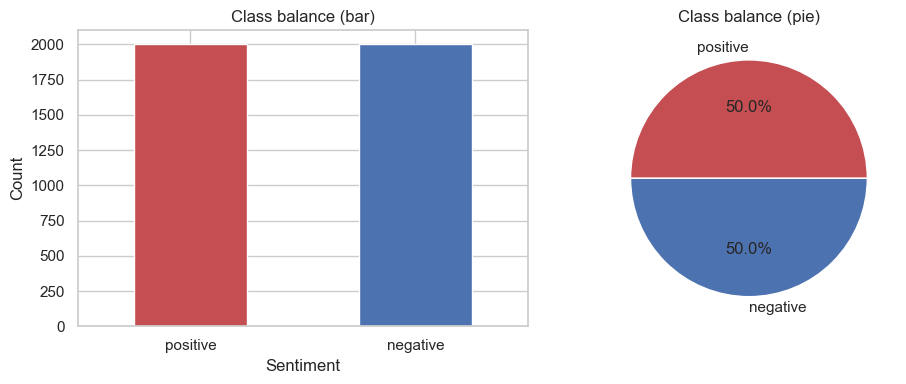

Saved: D:\ml project\Social media and sentiment analysis\notebooks\eda_class_balance.png


In [6]:
# Step 6 — EDA (part 1): samples, nulls, class balance — bar + pie — save PNG

print("Sample rows:")
print(df.sample(min(5, len(df)), random_state=42))
print()
print("Null counts:")
print(df.isna().sum())

counts = df["sentiment"].value_counts()
palette = {"negative": "#c44e52", "neutral": "#888888", "positive": "#4c72b0"}
bar_colors = [palette.get(str(i), "#999999") for i in counts.index]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts.plot(kind="bar", ax=axes[0], color=bar_colors)
axes[0].set_title("Class balance (bar)")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%", colors=bar_colors)
axes[1].set_title("Class balance (pie)")
plt.tight_layout()

out_balance = NOTEBOOK_DIR / "eda_class_balance.png"
plt.savefig(out_balance, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_balance)

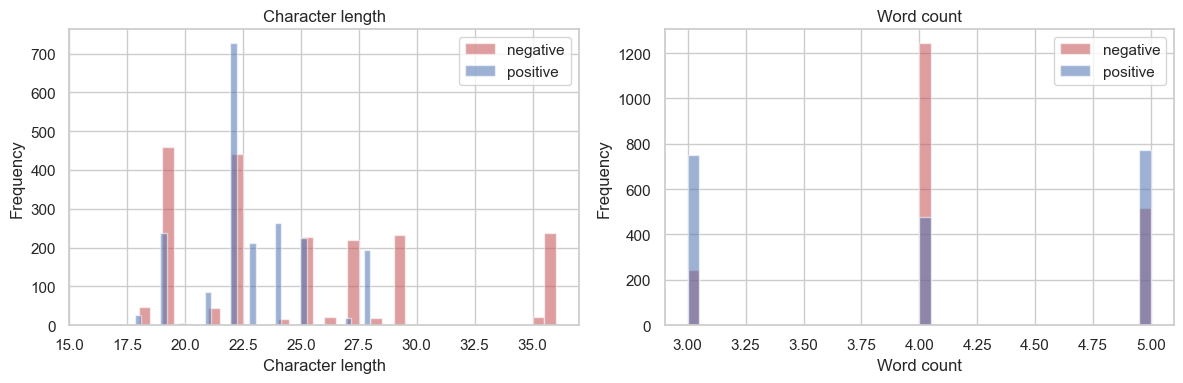

Saved: D:\ml project\Social media and sentiment analysis\notebooks\eda_length_by_sentiment.png


In [8]:
# Step 7 — EDA (part 2): tweet length by sentiment — save PNG

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PAL = {"negative": "#c44e52", "neutral": "#888888", "positive": "#4c72b0"}
order = ["negative", "neutral", "positive"]
for ax, col, title in zip(
    axes,
    ["char_len", "word_len"],
    ["Character length", "Word count"],
):
    for sentiment in order:
        subset = df.loc[df["sentiment"] == sentiment, col]
        if len(subset) == 0:
            continue
        ax.hist(
            subset,
            bins=40,
            alpha=0.55,
            label=sentiment,
            color=PAL[sentiment],
        )
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
out_len = NOTEBOOK_DIR / "eda_length_by_sentiment.png"
plt.savefig(out_len, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_len)

In [9]:
# Step 8 — Save sample dataset for the preprocessing pipeline

OUTPUT_CSV = DATA_DIR / "sample_dataset.csv"
export_cols = ["text", "sentiment", "target"]
df[export_cols].to_csv(OUTPUT_CSV, index=False)
print("Wrote:", OUTPUT_CSV)

Wrote: D:\ml project\Social media and sentiment analysis\data\sample_dataset.csv
